First 5 rows:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionL

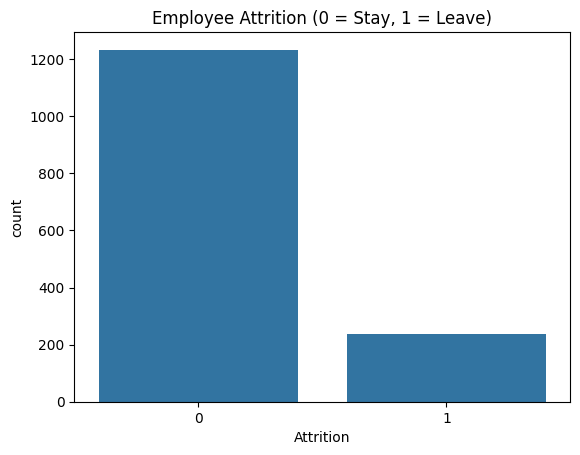

This chart shows the distribution of employee attrition, indicating a higher number of employees who stay versus those who leave.

Feature Shape: (1470, 44)

Accuracy: 0.8775510204081632

Confusion Matrix:
[[241  14]
 [ 22  17]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       255
           1       0.55      0.44      0.49        39

    accuracy                           0.88       294
   macro avg       0.73      0.69      0.71       294
weighted avg       0.87      0.88      0.87       294


Sample Probabilities (Stay, Leave):
[[0.93508199 0.06491801]
 [0.9973644  0.0026356 ]
 [0.65738822 0.34261178]
 [0.98714761 0.01285239]
 [0.94932286 0.05067714]]


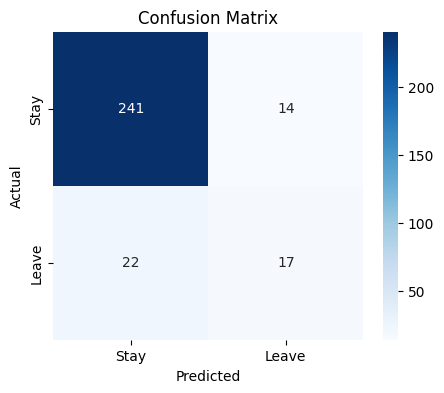

The confusion matrix visualizes the performance of the classification model, showing correctly and incorrectly classified instances.


Top Factors Affecting Attrition:
OverTime_Yes                        0.975324
JobRole_Laboratory Technician       0.780808
BusinessTravel_Travel_Frequently    0.717950
YearsAtCompany                      0.668289
MaritalStatus_Single                0.625524
NumCompaniesWorked                  0.509736
JobRole_Sales Representative        0.506542
YearsSinceLastPromotion             0.500860
BusinessTravel_Travel_Rarely        0.441246
JobRole_Research Scientist          0.398999
dtype: float64


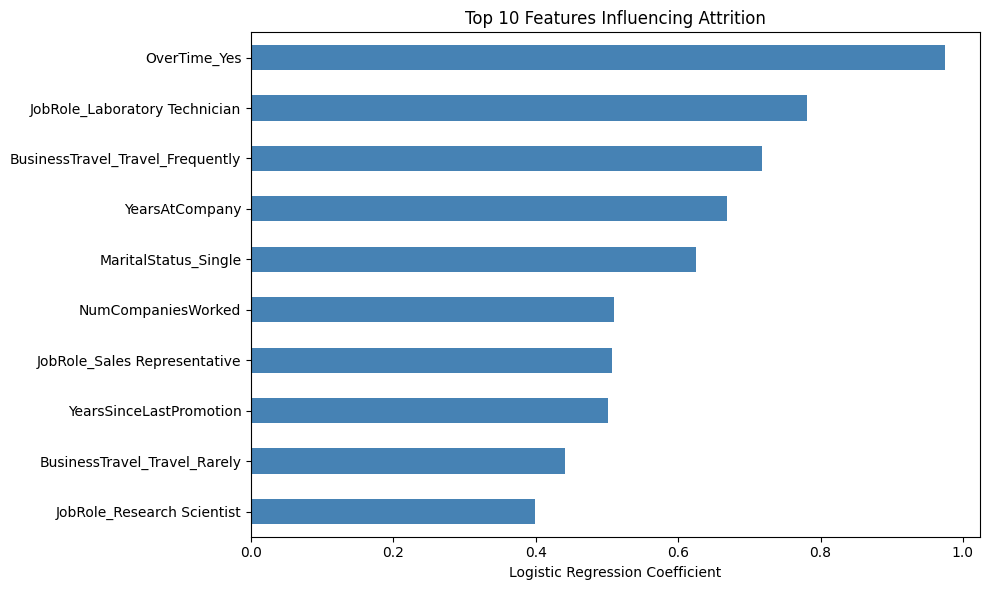

This bar chart highlights the top 10 features, based on logistic regression coefficients, that have the most significant impact on employee attrition.

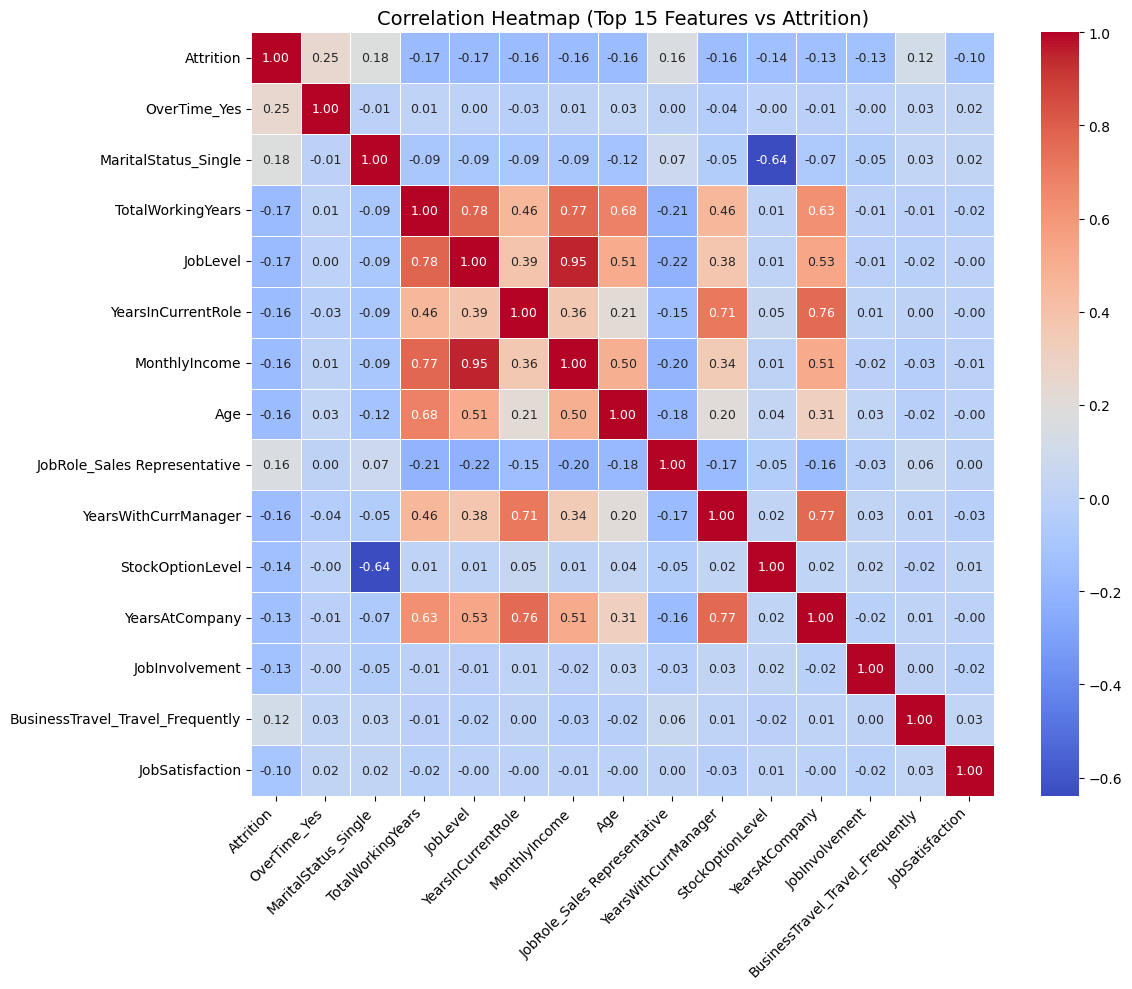

This heatmap displays the correlation between the top 15 features and attrition, revealing how these variables relate to each other and the target variable.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from IPython.display import Markdown, display

# ── 1. LOAD DATA ──────────────────────────────────────────────
df = pd.read_csv(r"/WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("First 5 rows:");       print(df.head())
print("\nDataset Info:");      print(df.info())
print("\nStatistical Summary:"); print(df.describe())

# ── 2. ENCODE TARGET ──────────────────────────────────────────
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print("\nAttrition Count:");   print(df['Attrition'].value_counts())

# ── 3. CHART 1 — Attrition Count ──────────────────────────────
plt.figure()
sns.countplot(x=df['Attrition'])
plt.title("Employee Attrition (0 = Stay, 1 = Leave)")
plt.show()
display(Markdown("This chart shows the distribution of employee attrition, indicating a higher number of employees who stay versus those who leave."))


# ── 5. PREPROCESS ─────────────────────────────────────────────
df = df.drop(['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours'], axis=1)
df = pd.get_dummies(df, drop_first=True)

X = df.drop('Attrition', axis=1)
y = df['Attrition']
print("Feature Shape:", X.shape)

# ── 6. TRAIN / TEST SPLIT ─────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── 7. SCALE ✅ (fixes ConvergenceWarning) ────────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ── 8. TRAIN MODEL ────────────────────────────────────────────
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# ── 9. EVALUATE ───────────────────────────────────────────────
y_pred = model.predict(X_test)
print("\nAccuracy:",          accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:");  print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:"); print(classification_report(y_test, y_pred))

y_prob = model.predict_proba(X_test)
print("\nSample Probabilities (Stay, Leave):"); print(y_prob[:5])

# ── 10. CHART 3 — Confusion Matrix Heatmap ────────────────────
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            cmap='Blues', xticklabels=['Stay','Leave'],
            yticklabels=['Stay','Leave'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()
display(Markdown("The confusion matrix visualizes the performance of the classification model, showing correctly and incorrectly classified instances."))

# ── 11. FEATURE IMPORTANCE ────────────────────────────────────
importance = pd.Series(model.coef_[0], index=X.columns)
importance = importance.sort_values(ascending=False)
print("\nTop Factors Affecting Attrition:"); print(importance.head(10))

# ── 12. CHART 4 — Feature Importance Bar ──────────────────────
plt.figure(figsize=(10, 6))
importance.head(10).plot(kind='barh', color='steelblue')
plt.title("Top 10 Features Influencing Attrition")
plt.xlabel("Logistic Regression Coefficient")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
display(Markdown("This bar chart highlights the top 10 features, based on logistic regression coefficients, that have the most significant impact on employee attrition."))

# ── 13. CHART 5 — Correlation Heatmap (Top 15 only) ───────────
plt.figure(figsize=(12, 10))
top_features = df.corr()['Attrition'].abs().sort_values(ascending=False).head(15).index
corr_matrix  = df[top_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            linewidths=0.5, linecolor='white', annot_kws={"size": 9})
plt.title("Correlation Heatmap (Top 15 Features vs Attrition)", fontsize=14)
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
display(Markdown("This heatmap displays the correlation between the top 15 features and attrition, revealing how these variables relate to each other and the target variable."))